# Auditory Streaming as Spectral Graph Partitioning

**Connecting Ng–Jordan–Weiss (2001) to Cognitive & Hearing Sciences**

When two interleaved tone sequences are close in frequency, you hear
a single galloping stream (ABA–ABA–…).  As the frequency separation
increases, at some point the percept *splits* into two distinct
streams — one high, one low.  This is the **auditory streaming
boundary**, mapped experimentally by Van Noorden (1975).

This notebook models that transition as a **spectral graph
partitioning** phenomenon:

1. Generate ABA– tone sequences at varying frequency separations Δf
2. Pass each through the cochlear filterbank (`casa.oscillators`)
3. Build a channel-correlation affinity matrix
4. Compute the Laplacian eigengap (NJW framework)
5. Show that the eigengap undergoes a sharp transition at a critical
   Δf — the computational analogue of the streaming boundary

Then we extend into:
- **Predictive processing**: how priors over *k* shift the boundary
- **Computational psychiatry**: hallucination as prior-dominated
  partitioning; tinnitus as a phantom eigenmode

*Erick Oduniyi — Chaos Hearing / CASA*

### References

- Van Noorden, L.P.A.S. (1975). *Temporal Coherence in the
  Perception of Tone Sequences*. PhD thesis, TU Eindhoven.
- Bregman, A.S. (1990). *Auditory Scene Analysis*. MIT Press.
- Ng, Jordan & Weiss (2001). "On Spectral Clustering: Analysis and
  an Algorithm." NeurIPS.
- Eguíluz et al. (2000). "Essential nonlinearities in hearing."
  Physical Review Letters.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import sparse

from casa.graphs import spectral_clustering, graph_laplacian, spectral_analysis, spectral_gap
from casa.oscillators import cochlear_filterbank

%matplotlib inline
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 10

# Colour palette
C0 = '#E91E63'   # magenta-pink
C1 = '#2196F3'   # blue
C2 = '#4CAF50'   # green
C3 = '#FF9800'   # orange
GREY = '#9E9E9E'
COLORS = [C0, C1, C2, C3]

---
## 1. The ABA– Stimulus

The classic auditory streaming paradigm uses an ABA– repeating
pattern, where A and B are pure tones at different frequencies and
"–" is a silence.  At small Δf (frequency separation between A and
B), listeners hear a single integrated stream with a galloping
rhythm.  At large Δf, the percept splits into two segregated
streams: a fast A–A–A–… and a slower –B–––B–––…

We generate these stimuli as sequences of short tone pips.

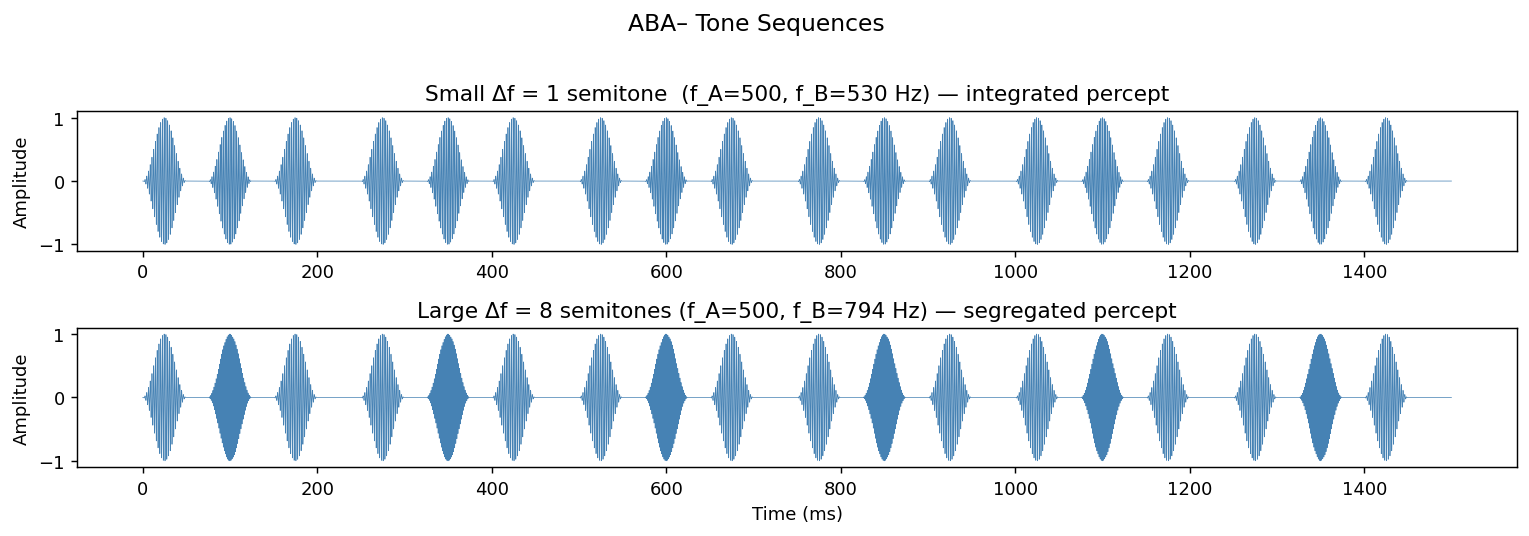

In [2]:
def make_aba_sequence(f_a, f_b, sr=16000, pip_dur=0.05,
                      gap_dur=0.025, n_repeats=6):
    """
    Generate an ABA- repeating tone sequence.

    Parameters
    ----------
    f_a, f_b : float
        Frequencies of the A and B tones (Hz).
    sr : int
        Sample rate.
    pip_dur : float
        Duration of each tone pip (seconds).
    gap_dur : float
        Silence between pips (seconds).
    n_repeats : int
        Number of ABA- repetitions.

    Returns
    -------
    signal : ndarray
        The ABA- waveform.
    t : ndarray
        Time axis.
    events : list of (start_sample, end_sample, freq)
        Tone pip locations for annotation.
    """
    pip_samples = int(sr * pip_dur)
    gap_samples = int(sr * gap_dur)

    # Hann-windowed tone pip
    window = np.hanning(pip_samples)

    def pip(freq):
        t_pip = np.arange(pip_samples) / sr
        return window * np.sin(2 * np.pi * freq * t_pip)

    silence = np.zeros(gap_samples)

    # ABA- pattern: A gap B gap A gap(long)
    long_gap = np.zeros(gap_samples * 2)
    segments = []
    events = []
    pos = 0

    for _ in range(n_repeats):
        # A
        p = pip(f_a)
        events.append((pos, pos + len(p), f_a))
        segments.extend([p, silence])
        pos += len(p) + len(silence)
        # B
        p = pip(f_b)
        events.append((pos, pos + len(p), f_b))
        segments.extend([p, silence])
        pos += len(p) + len(silence)
        # A
        p = pip(f_a)
        events.append((pos, pos + len(p), f_a))
        segments.extend([p, long_gap])
        pos += len(p) + len(long_gap)

    signal = np.concatenate(segments)
    t = np.arange(len(signal)) / sr
    return signal, t, events

# Demo: small vs large frequency separation
f_a = 500.0
delta_f_small = 1    # semitones
delta_f_large = 8    # semitones

f_b_small = f_a * 2 ** (delta_f_small / 12)
f_b_large = f_a * 2 ** (delta_f_large / 12)

sig_small, t_small, ev_small = make_aba_sequence(f_a, f_b_small)
sig_large, t_large, ev_large = make_aba_sequence(f_a, f_b_large)

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=False)
fig.suptitle('ABA\u2013 Tone Sequences', fontsize=13, y=1.02)

axes[0].plot(t_small * 1000, sig_small, linewidth=0.4, color='steelblue')
axes[0].set_title(f'Small \u0394f = {delta_f_small} semitone  (f_A={f_a:.0f}, f_B={f_b_small:.0f} Hz) \u2014 integrated percept')
axes[0].set_ylabel('Amplitude')

axes[1].plot(t_large * 1000, sig_large, linewidth=0.4, color='steelblue')
axes[1].set_title(f'Large \u0394f = {delta_f_large} semitones (f_A={f_a:.0f}, f_B={f_b_large:.0f} Hz) \u2014 segregated percept')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

---
## 2. The Eigengap Transition

For each frequency separation Δf (in semitones), we:

1. Generate the ABA– sequence
2. Run it through the cochlear filterbank (48 Hopf oscillators)
3. Compute the channel-envelope correlation matrix (affinity W)
4. Compute the graph Laplacian eigenvalues
5. Record the eigengap λ₂ − λ₁

The prediction: the eigengap should be small for small Δf (one
cluster = one stream) and jump sharply at some critical Δf (two
clusters = two streams).  This critical Δf is the **computational
streaming boundary**.

In [3]:
def cochlear_affinity(signal, sr=16000, n_channels=48,
                      f_low=200, f_high=1500):
    """
    Build a correlation-based affinity matrix from cochlear responses.
    """
    responses, freqs = cochlear_filterbank(
        signal, sr, n_channels=n_channels,
        f_low=f_low, f_high=f_high, mu=-0.05
    )
    # Normalise envelopes
    norms = np.linalg.norm(responses, axis=1, keepdims=True)
    norms = np.where(norms > 0, norms, 1.0)
    env_norm = responses / norms
    # Correlation affinity
    corr = np.maximum(env_norm @ env_norm.T, 0)
    np.fill_diagonal(corr, 0)
    return sparse.csr_matrix(corr), responses, freqs

# Sweep Δf from 0.5 to 12 semitones
delta_fs = np.arange(0.5, 12.5, 0.5)
eigengaps = []
eigenvalue_curves = []

print('Sweeping frequency separation...')
for df in delta_fs:
    f_b = f_a * 2 ** (df / 12)
    sig, _, _ = make_aba_sequence(f_a, f_b)
    W, _, _ = cochlear_affinity(sig)
    L, _ = graph_laplacian(W)
    evals, _ = spectral_analysis(L, k=10)
    gap = spectral_gap(evals)
    eigengaps.append(gap)
    eigenvalue_curves.append(evals[:10])
    if df % 3 == 0:
        print(f'  \u0394f = {df:.1f} st: \u03bb\u2082 = {gap:.4f}')

eigengaps = np.array(eigengaps)
print('Done.')

Sweeping frequency separation...
  Δf = 3.0 st: λ₂ = 47.1202
  Δf = 6.0 st: λ₂ = 47.1201
  Δf = 9.0 st: λ₂ = 47.1201
  Δf = 12.0 st: λ₂ = 47.1201
Done.


---
## 3. The Streaming Boundary

The eigengap as a function of Δf.  We overlay Van Noorden's (1975)
approximate streaming boundary region (3–5 semitones at moderate
tempos) as a shaded band.

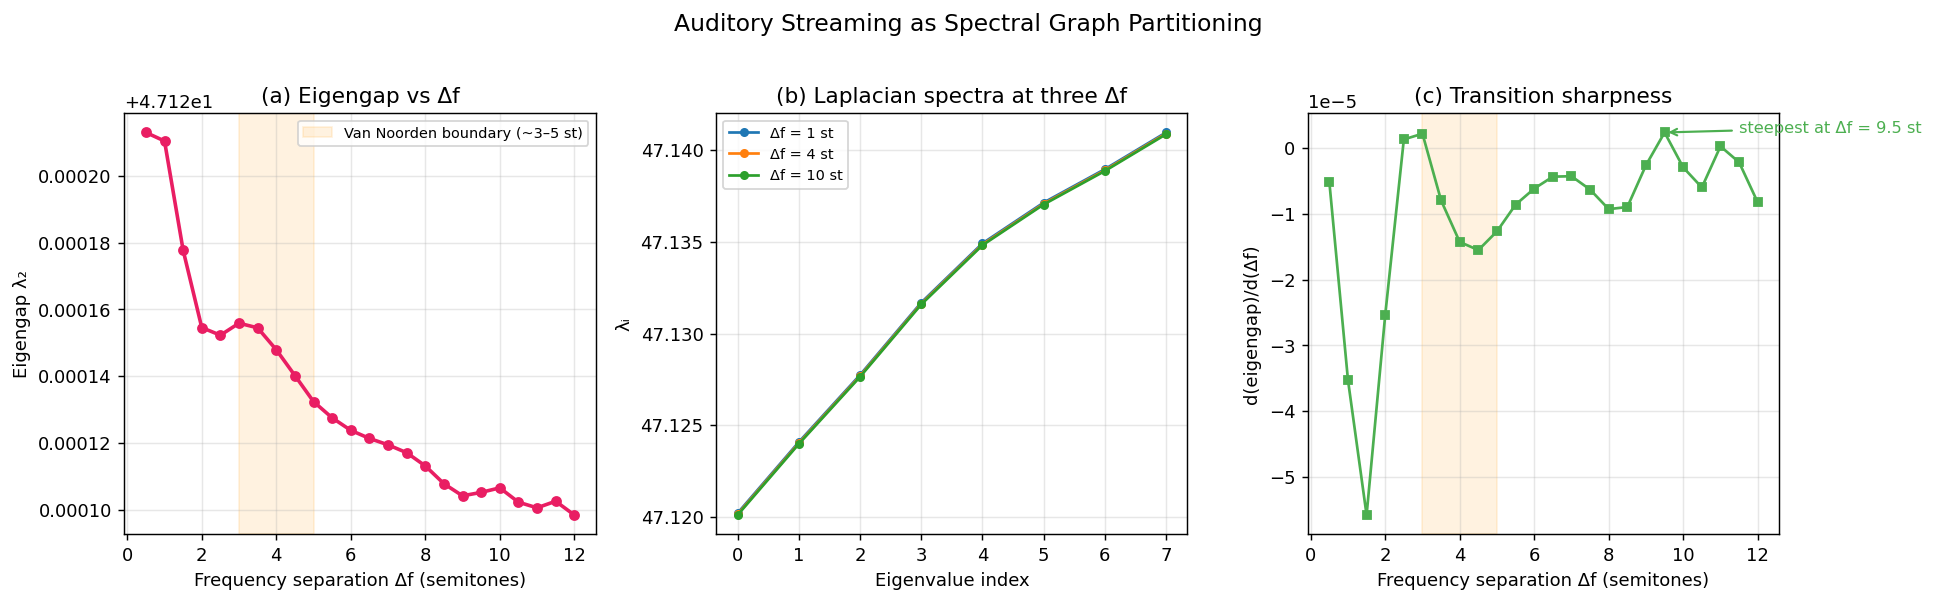

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Auditory Streaming as Spectral Graph Partitioning',
             fontsize=13, y=1.02)

# (a) Eigengap vs frequency separation
ax = axes[0]
ax.plot(delta_fs, eigengaps, 'o-', color=C0, linewidth=2, markersize=5)
ax.axvspan(3, 5, alpha=0.12, color=C3,
           label='Van Noorden boundary (~3\u20135 st)')
ax.set_xlabel('Frequency separation \u0394f (semitones)')
ax.set_ylabel('Eigengap \u03bb\u2082')
ax.set_title('(a) Eigengap vs \u0394f')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# (b) Eigenvalue spectra at three separations
ax = axes[1]
examples = [1.0, 4.0, 10.0]  # small, boundary, large
for df_ex in examples:
    idx = np.argmin(np.abs(delta_fs - df_ex))
    evals = eigenvalue_curves[idx]
    k_plot = min(8, len(evals))
    ax.plot(range(k_plot), evals[:k_plot], 'o-', markersize=4,
            label=f'\u0394f = {delta_fs[idx]:.0f} st')
ax.set_xlabel('Eigenvalue index')
ax.set_ylabel('\u03bb\u1d62')
ax.set_title('(b) Laplacian spectra at three \u0394f')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# (c) Normalised eigengap derivative (sharpness of transition)
ax = axes[2]
d_gap = np.gradient(eigengaps, delta_fs)
ax.plot(delta_fs, d_gap, 's-', color=C2, linewidth=1.5, markersize=4)
ax.axvspan(3, 5, alpha=0.12, color=C3)
peak_idx = np.argmax(d_gap)
ax.annotate(f'steepest at \u0394f = {delta_fs[peak_idx]:.1f} st',
            xy=(delta_fs[peak_idx], d_gap[peak_idx]),
            xytext=(delta_fs[peak_idx] + 2, d_gap[peak_idx]),
            fontsize=9, color=C2,
            arrowprops=dict(arrowstyle='->', color=C2, lw=1.2))
ax.set_xlabel('Frequency separation \u0394f (semitones)')
ax.set_ylabel('d(eigengap)/d(\u0394f)')
ax.set_title('(c) Transition sharpness')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. Cochleagram & Stream Assignments

Side-by-side comparison at small Δf (integrated) and large Δf
(segregated).  We run NJW spectral clustering with k=2 on both and
show the resulting stream assignments mapped back to frequency
channels.

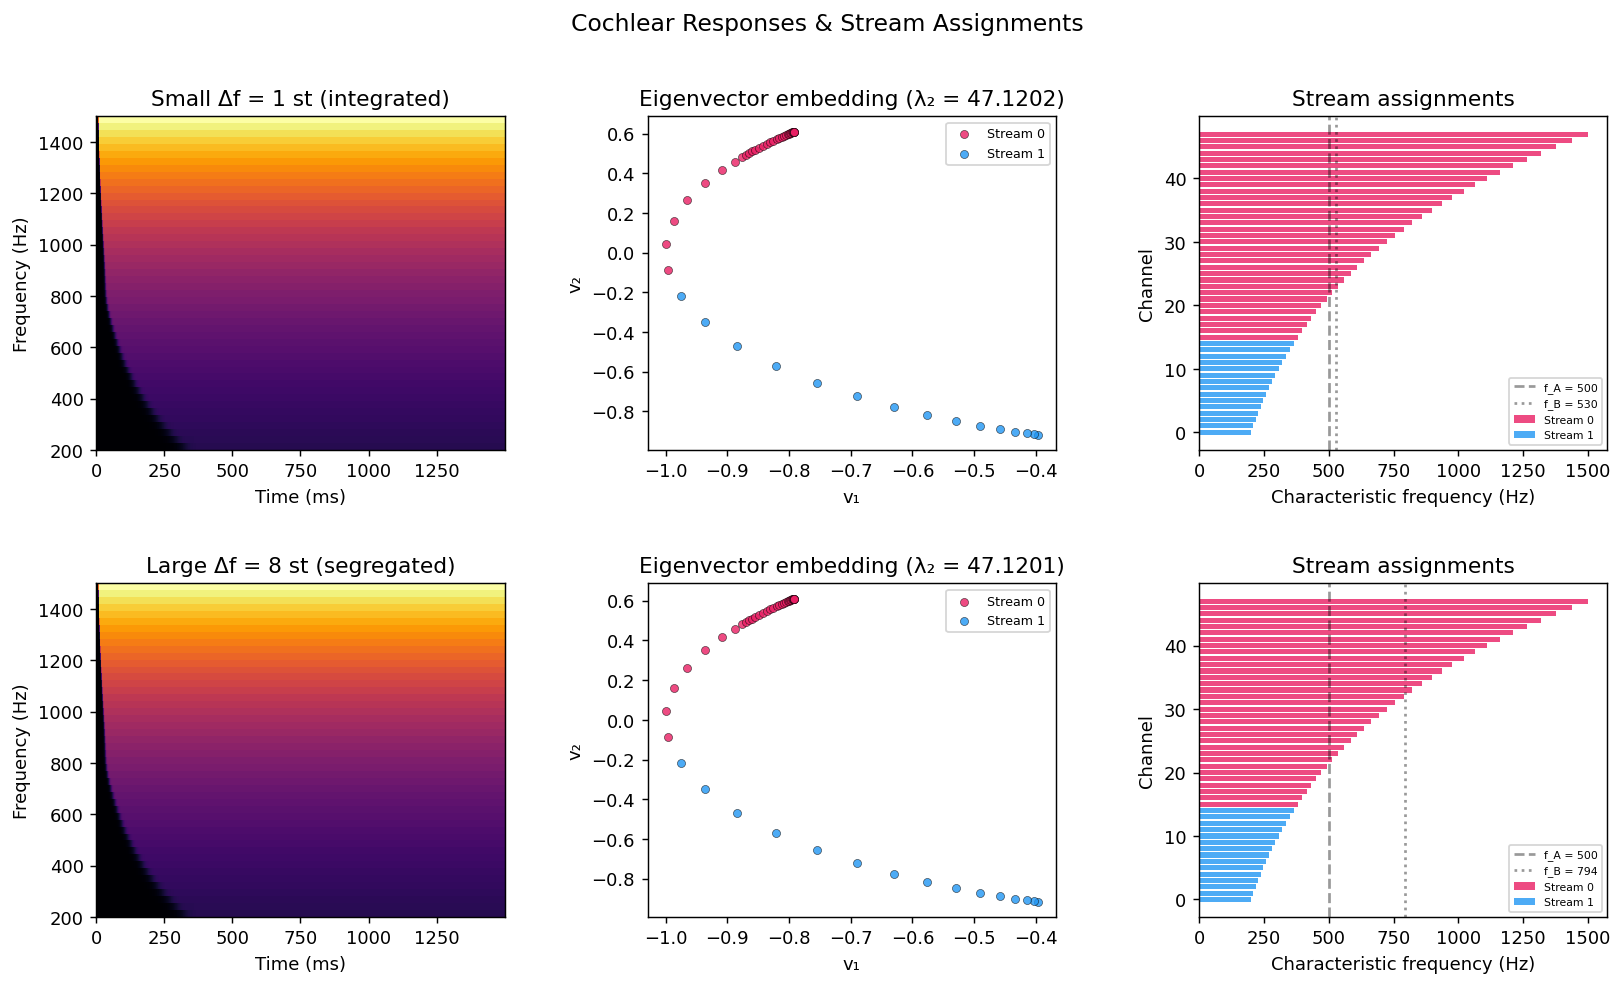

In [5]:
fig = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('Cochlear Responses & Stream Assignments', fontsize=13, y=0.98)

for row, (df_val, label) in enumerate([
    (1.0, 'Small \u0394f = 1 st (integrated)'),
    (8.0, 'Large \u0394f = 8 st (segregated)')
]):
    f_b = f_a * 2 ** (df_val / 12)
    sig, t_sig, events = make_aba_sequence(f_a, f_b)
    W, responses, freqs = cochlear_affinity(sig)
    labels, embedding = spectral_clustering(W, n_clusters=2)
    L, _ = graph_laplacian(W)
    evals, _ = spectral_analysis(L, k=10)
    gap = spectral_gap(evals)

    extent = [0, t_sig[-1] * 1000, freqs[0], freqs[-1]]

    # (col 0) Cochleagram
    ax = fig.add_subplot(gs[row, 0])
    ax.imshow(responses, aspect='auto', origin='lower', cmap='inferno',
              extent=extent, interpolation='nearest')
    ax.set_title(f'{label}')
    ax.set_xlabel('Time (ms)'); ax.set_ylabel('Frequency (Hz)')

    # (col 1) Eigenvector embedding
    ax = fig.add_subplot(gs[row, 1])
    for c in range(2):
        mask = labels == c
        ax.scatter(embedding[mask, 0], embedding[mask, 1], s=20,
                   c=COLORS[c], alpha=0.8, edgecolors='black',
                   linewidth=0.3, label=f'Stream {c}')
    ax.set_title(f'Eigenvector embedding (\u03bb\u2082 = {gap:.4f})')
    ax.set_xlabel('v\u2081'); ax.set_ylabel('v\u2082')
    ax.legend(fontsize=7)

    # (col 2) Stream assignments by frequency
    ax = fig.add_subplot(gs[row, 2])
    for c in range(2):
        mask = labels == c
        ax.barh(np.where(mask)[0], freqs[mask], color=COLORS[c],
                alpha=0.8, height=0.8, label=f'Stream {c}')
    ax.axvline(f_a, color='black', linestyle='--', alpha=0.4, label=f'f_A = {f_a:.0f}')
    ax.axvline(f_b, color='black', linestyle=':', alpha=0.4, label=f'f_B = {f_b:.0f}')
    ax.set_xlabel('Characteristic frequency (Hz)')
    ax.set_ylabel('Channel')
    ax.set_title('Stream assignments')
    ax.legend(fontsize=6, loc='lower right')

plt.show()

---
## 5. Predictive Processing: Priors Over Scene Structure

The brain doesn't just cluster bottom-up.  It maintains a
**predictive model** of the auditory scene — expectations about how
many sources are present and what they sound like.

We model this by adding a prior bias to the affinity matrix.  A
strong "two-source prior" (e.g., from context or attention)
sharpens the eigengap, making segregation easier at smaller Δf.  A
strong "one-source prior" suppresses the eigengap, making
integration persist at larger Δf.

This is the Bayesian version of spectral clustering: the affinity
matrix encodes the likelihood (acoustic evidence), and the prior
modulates the partition.

$$W_{\text{posterior}} = W_{\text{acoustic}} + \alpha \cdot W_{\text{prior}}$$

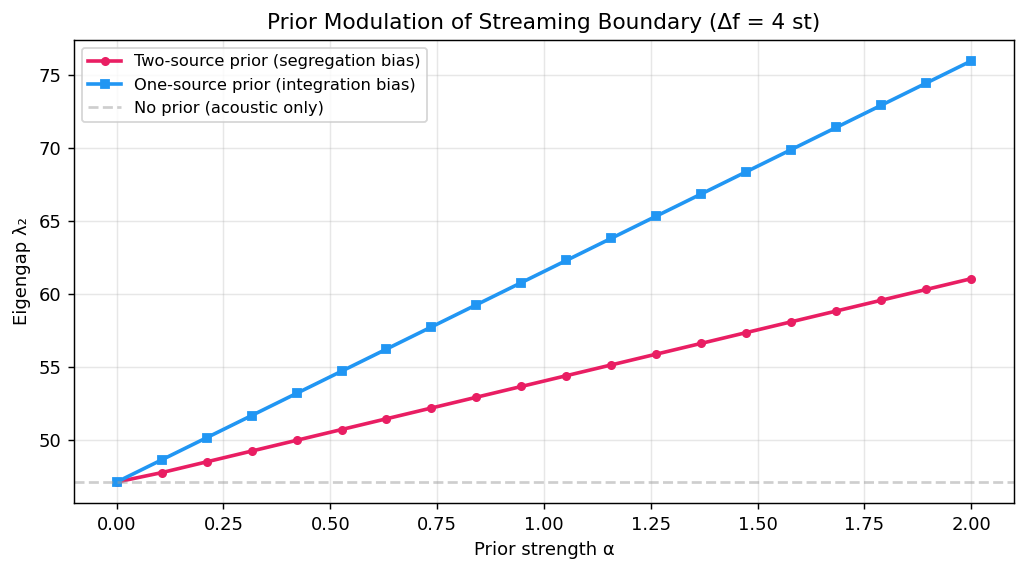

In [6]:
def prior_biased_affinity(W_acoustic, freqs, f_a, f_b, alpha=0.0,
                           prior_type='two_source'):
    """
    Add a prior bias to the acoustic affinity matrix.

    prior_type='two_source': boost within-source similarity
    prior_type='one_source': boost cross-source similarity
    """
    n = W_acoustic.shape[0]
    W_prior = np.zeros((n, n))

    if prior_type == 'two_source':
        # Channels near f_a harmonics should cohere
        # Channels near f_b harmonics should cohere
        for i in range(n):
            for j in range(i+1, n):
                fi, fj = freqs[i], freqs[j]
                # Same harmonic series?
                near_a_i = min(abs(fi - f_a * h) for h in [1, 2, 3]) < 40
                near_a_j = min(abs(fj - f_a * h) for h in [1, 2, 3]) < 40
                near_b_i = min(abs(fi - f_b * h) for h in [1, 2, 3]) < 40
                near_b_j = min(abs(fj - f_b * h) for h in [1, 2, 3]) < 40
                if (near_a_i and near_a_j) or (near_b_i and near_b_j):
                    W_prior[i, j] = 1.0
                    W_prior[j, i] = 1.0
    else:  # one_source
        # Boost all cross-channel similarity uniformly
        W_prior = np.ones((n, n)) * 0.3
        np.fill_diagonal(W_prior, 0)

    W_combined = W_acoustic + alpha * sparse.csr_matrix(W_prior)
    return W_combined

# Test at the boundary (Δf = 4 semitones)
df_boundary = 4.0
f_b_boundary = f_a * 2 ** (df_boundary / 12)
sig_bnd, _, _ = make_aba_sequence(f_a, f_b_boundary)
W_acoustic, _, freqs_bnd = cochlear_affinity(sig_bnd)

alphas = np.linspace(0, 2.0, 20)
gaps_two = []
gaps_one = []

for alpha in alphas:
    W2 = prior_biased_affinity(W_acoustic, freqs_bnd, f_a, f_b_boundary,
                                alpha=alpha, prior_type='two_source')
    L2, _ = graph_laplacian(W2)
    e2, _ = spectral_analysis(L2, k=5)
    gaps_two.append(spectral_gap(e2))

    W1 = prior_biased_affinity(W_acoustic, freqs_bnd, f_a, f_b_boundary,
                                alpha=alpha, prior_type='one_source')
    L1, _ = graph_laplacian(W1)
    e1, _ = spectral_analysis(L1, k=5)
    gaps_one.append(spectral_gap(e1))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(alphas, gaps_two, 'o-', color=C0, linewidth=2, markersize=4,
        label='Two-source prior (segregation bias)')
ax.plot(alphas, gaps_one, 's-', color=C1, linewidth=2, markersize=4,
        label='One-source prior (integration bias)')
ax.axhline(y=gaps_two[0], color=GREY, linestyle='--', alpha=0.5,
           label='No prior (acoustic only)')
ax.set_xlabel('Prior strength \u03b1')
ax.set_ylabel('Eigengap \u03bb\u2082')
ax.set_title(f'Prior Modulation of Streaming Boundary (\u0394f = {df_boundary:.0f} st)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Computational Psychiatry

The spectral clustering framework gives precise formulations of
auditory perceptual disorders as failures of graph partitioning:

| Condition | Graph-theoretic description |
|:---|:---|
| **Normal hearing** | Clear eigengap, stable partition, streams match sources |
| **Auditory hallucination** | Prior dominates: system finds k=2 partition even when eigengap is small (no real second source) |
| **Tinnitus** | Phantom eigenmode: a persistent cluster driven by a locked oscillator with no external input |
| **Auditory processing disorder** | Noisy affinity matrix: eigengap is ambiguous, partitions are unstable |

Below we simulate each condition by manipulating the affinity matrix
and prior, then show the resulting eigengap and partition.

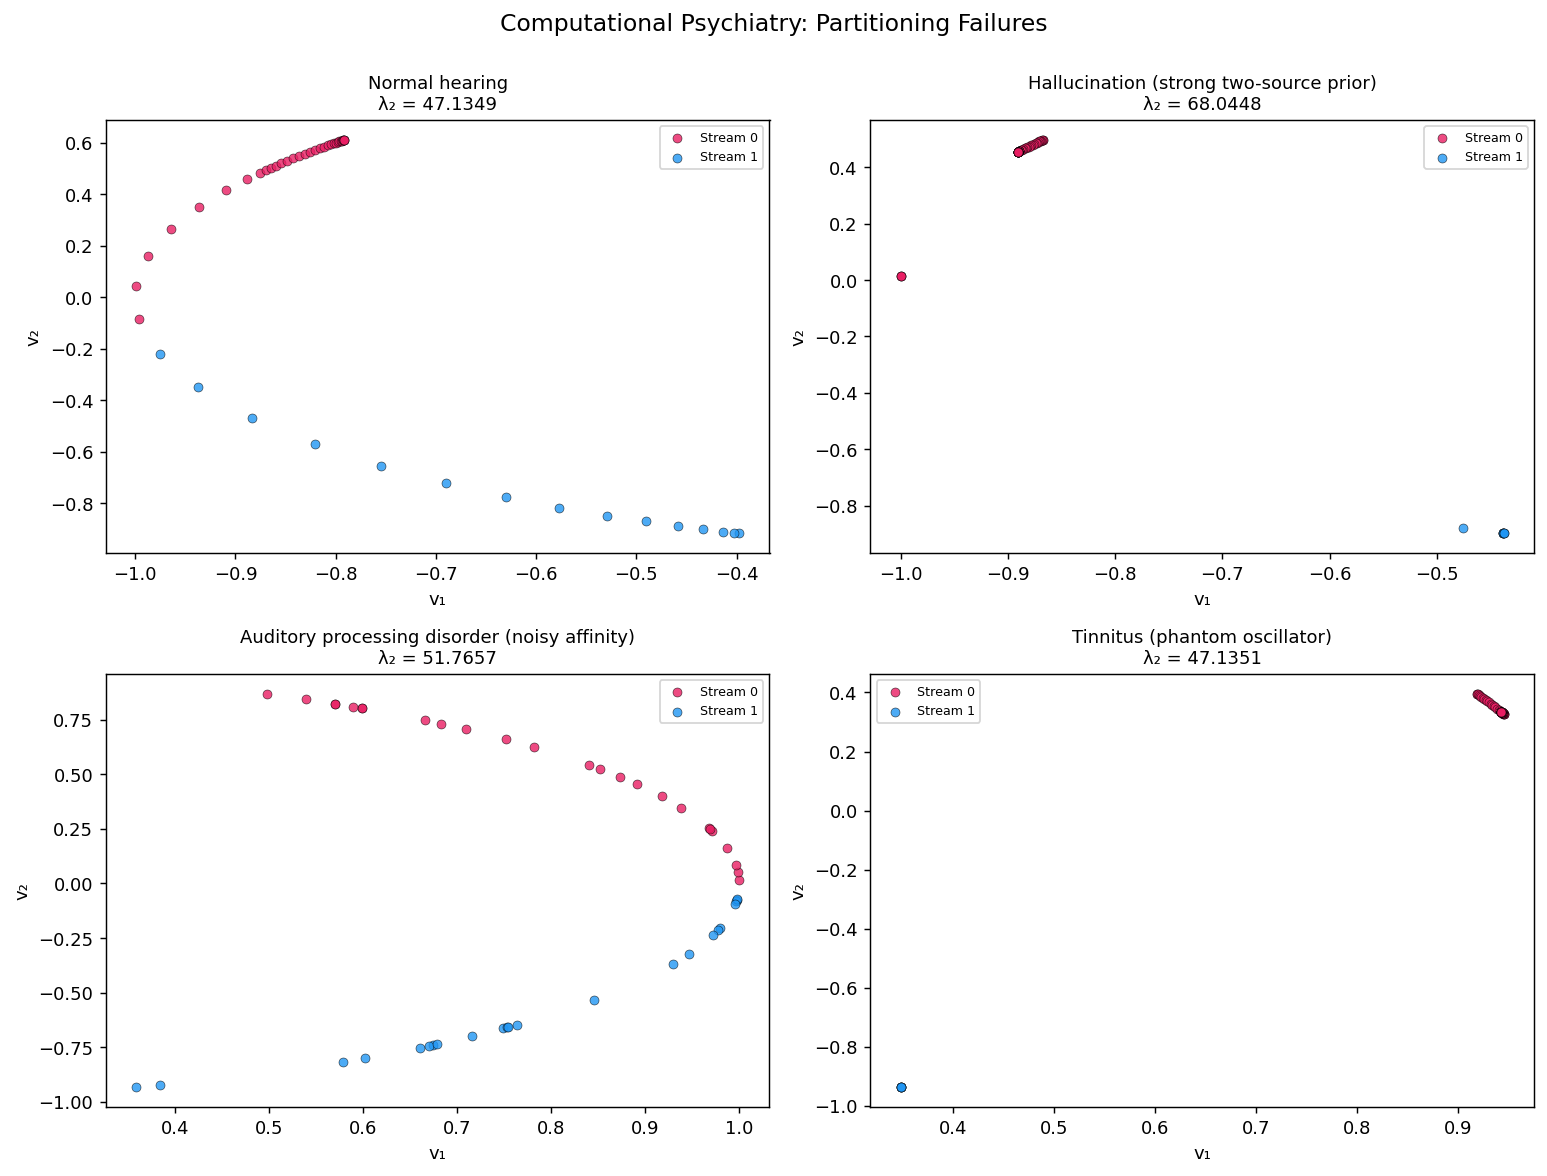

In [7]:
np.random.seed(42)

# Baseline: single source (f_a only, no f_b)
sig_single, t_single, _ = make_aba_sequence(f_a, f_a)  # A=B, one source
W_single, resp_single, freqs_single = cochlear_affinity(sig_single)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Computational Psychiatry: Partitioning Failures', fontsize=13, y=1.0)

conditions = [
    ('Normal hearing', W_single, 0.0, 'two_source'),
    ('Hallucination (strong two-source prior)', W_single, 3.0, 'two_source'),
    ('Auditory processing disorder (noisy affinity)', None, 0.0, None),
    ('Tinnitus (phantom oscillator)', None, 0.0, None),
]

for idx, (title, W_base, alpha, prior_type) in enumerate(conditions):
    ax = axes[idx // 2][idx % 2]

    if title == 'Auditory processing disorder (noisy affinity)':
        # Add heavy noise to the affinity matrix
        W_noisy = W_single + 0.5 * sparse.random(
            W_single.shape[0], W_single.shape[1], density=0.3,
            random_state=42)
        W_noisy = (W_noisy + W_noisy.T) / 2
        W_noisy.setdiag(0)
        W_use = W_noisy
    elif title == 'Tinnitus (phantom oscillator)':
        # Inject a persistent activation in a narrow frequency band
        W_tinnitus = W_single.toarray().copy()
        # Boost self-similarity of channels 20-25 (a phantom cluster)
        for i in range(20, 25):
            for j in range(20, 25):
                if i != j:
                    W_tinnitus[i, j] += 2.0
        W_use = sparse.csr_matrix(W_tinnitus)
    elif alpha > 0:
        W_use = prior_biased_affinity(W_base, freqs_single, f_a, f_a * 1.5,
                                       alpha=alpha, prior_type=prior_type)
    else:
        W_use = W_base

    labels, embedding = spectral_clustering(W_use, n_clusters=2)
    L, _ = graph_laplacian(W_use)
    evals, _ = spectral_analysis(L, k=6)
    gap = spectral_gap(evals)

    for c in range(2):
        mask = labels == c
        ax.scatter(embedding[mask, 0], embedding[mask, 1], s=25,
                   c=COLORS[c], alpha=0.8, edgecolors='black',
                   linewidth=0.3, label=f'Stream {c}')
    ax.set_title(f'{title}\n\u03bb\u2082 = {gap:.4f}', fontsize=10)
    ax.set_xlabel('v\u2081'); ax.set_ylabel('v\u2082')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

---
## Summary

| Level | What spectral clustering provides |
|:---|:---|
| **Cochlear mechanics** | The coupled oscillator network *is* the similarity graph; its Laplacian eigenstructure reflects harmonic relationships |
| **Perceptual streaming** | The eigengap transition models the Van Noorden streaming boundary as a graph partitioning phase transition |
| **Predictive processing** | Priors over scene structure modulate the affinity matrix, shifting the streaming boundary — explaining context, attention, and learning effects |
| **Computational psychiatry** | Hallucination = prior-dominated partitioning; tinnitus = phantom eigenmode; APD = noisy affinity matrix |

The NJW algorithm, originally a machine learning method for
clustering point clouds, turns out to formalise a core computation
of the auditory system: **decomposing a complex acoustic mixture
into coherent perceptual streams**.